# Dynamic Programming for MDPs
## Grid World: Policy Evaluation, Policy Iteration, and Value Iteration

### What You'll Learn

- How to formalize sequential decision problems as **Markov Decision Processes (MDPs)**
- The **Bellman Expectation** and **Bellman Optimality** equations and their role as the foundation of DP methods
- How to implement **Policy Evaluation** to compute the value function of a given policy
- How to implement **Policy Iteration** (evaluate + improve) to find optimal policies
- How to implement **Value Iteration** using the Bellman optimality backup
- How to build a flexible **Grid World** environment from scratch
- How to **visualize** value functions, policies, and convergence behavior
- How to **verify** algorithm correctness via hand-solved linear systems

### The Big Picture

Imagine a robot placed in a grid-shaped room with one or more exits. The robot wants to reach an exit as quickly as possible and knows the complete layout of the room -- where the walls are, where the exits are, and how movement works. **Dynamic Programming** (DP) exploits this perfect knowledge to compute the best action in *every* square of the grid, all at once, without the robot ever having to try things out through trial and error.

This is fundamentally different from **model-free reinforcement learning** (like Q-learning or SARSA), where the agent has no map and must *learn* by interacting with the environment. DP is *planning* with a known model; model-free RL is *learning* from experience. Understanding DP first gives you the theoretical foundation that all other RL methods build upon.

### Prerequisites

- Linear algebra (matrix equations, systems of linear equations)
- Basic probability (expectation, conditional probability)
- Python, NumPy, Matplotlib

### References

1. **Sutton & Barto** — *Reinforcement Learning: An Introduction*, 2nd Edition, Chapters 3 & 4
2. **Bertsekas, D.P.** — *Dynamic Programming and Optimal Control*, Vols. I & II
3. **Puterman, M.L.** — *Markov Decision Processes: Discrete Stochastic Dynamic Programming*

---
## 1. Markov Decision Processes

A **Markov Decision Process (MDP)** is defined by the tuple $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$ where:

| Symbol | Meaning |
|--------|---------|
| $\mathcal{S}$ | Finite set of **states** |
| $\mathcal{A}$ | Finite set of **actions** |
| $P(s' \mid s, a)$ | **Transition probability**: probability of reaching state $s'$ from state $s$ under action $a$ |
| $R(s, a, s')$ | **Reward function**: immediate reward received on transition $(s, a, s')$ |
| $\gamma \in [0, 1)$ | **Discount factor**: trades off immediate vs. future rewards |

### The Markov Property

The defining characteristic of an MDP is the **Markov property**: the future is conditionally independent of the past given the present state:

$$P(S_{t+1} = s' \mid S_t = s, A_t = a, S_{t-1}, A_{t-1}, \ldots) = P(S_{t+1} = s' \mid S_t = s, A_t = a)$$

### State Transitions

The dynamics of an MDP are fully specified by the **state transition probability function**:

$$p(s', r \mid s, a) = P(S_{t+1} = s', R_{t+1} = r \mid S_t = s, A_t = a)$$

From this we can derive:
- **State transition probabilities**: $p(s' \mid s, a) = \sum_{r} p(s', r \mid s, a)$
- **Expected reward**: $r(s, a) = \mathbb{E}[R_{t+1} \mid S_t = s, A_t = a] = \sum_{r} r \sum_{s'} p(s', r \mid s, a)$

### Discount Factor

The **return** $G_t$ is the discounted sum of future rewards:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

When $\gamma < 1$, this sum is bounded: $|G_t| \leq \frac{R_{\max}}{1 - \gamma}$. The discount factor $\gamma$ controls the agent's **horizon**: values near 0 make the agent myopic, values near 1 make it far-sighted.

### Intuitive MDP Analogy

All of the symbols above map to a simple real-world picture. Think of **GPS navigation**:

| MDP Concept | GPS Analogy | Grid World Mapping |
|---|---|---|
| States $\mathcal{S}$ | Intersections on the map | Squares on the grid |
| Actions $\mathcal{A}$ | Roads you can take from each intersection | UP, RIGHT, DOWN, LEFT |
| Transitions $P$ | Which intersection each road leads to (could be probabilistic with traffic) | Deterministic: action always moves you one square (or bounces off walls) |
| Rewards $R$ | Fuel cost per road segment (negative), or time saved | -1 per step (every move costs something) |
| Discount $\gamma$ | How much you value saving time now vs. later | $\gamma = 0.99$: you care almost as much about rewards 100 steps away; $\gamma = 0.5$: very short-sighted |

The **Markov property** in plain English: *to decide what to do, you only need to know where you are right now -- not how you got there.* Your GPS does not care which route you took to reach the current intersection; it only needs your current location to compute the best remaining route. This is what makes MDPs tractable: the full history is compressed into a single state.

---
## 2. Bellman Equations

### State-Value Function

The **state-value function** $V^\pi(s)$ gives the expected return starting from state $s$ and following policy $\pi$:

$$V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s]$$

### Action-Value Function

The **action-value function** $Q^\pi(s, a)$ gives the expected return starting from state $s$, taking action $a$, then following $\pi$:

$$Q^\pi(s, a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a]$$

### Relationship between $V$ and $Q$

$$V^\pi(s) = \sum_{a} \pi(a \mid s) \, Q^\pi(s, a)$$

$$Q^\pi(s, a) = \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V^\pi(s') \right]$$

### Bellman Expectation Equation

Substituting the $Q$-$V$ relationship into the definition of $V^\pi$, we obtain the **Bellman Expectation Equation**:

$$\boxed{V^\pi(s) = \sum_{a} \pi(a \mid s) \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V^\pi(s') \right]}$$

This is a system of $|\mathcal{S}|$ linear equations in $|\mathcal{S}|$ unknowns. For the $Q$-value version:

$$Q^\pi(s, a) = \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma \sum_{a'} \pi(a' \mid s') Q^\pi(s', a') \right]$$

### Bellman Optimality Equation

The **optimal value function** $V^*(s)$ satisfies the **Bellman Optimality Equation**:

$$\boxed{V^*(s) = \max_{a} \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V^*(s') \right]}$$

For the optimal action-value function:

$$Q^*(s, a) = \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma \max_{a'} Q^*(s', a') \right]$$

The key difference: the Bellman **Expectation** equation averages over actions according to $\pi$, while the Bellman **Optimality** equation takes the **max** over actions. The optimality equation is nonlinear (due to the max), so it cannot be solved as a simple linear system.

### Bellman Equations in Plain English

Before diving into the math, let's build intuition for what the Bellman equations actually say:

- **Value $V(s)$** = a "how good is it to be here?" score. More precisely, it is the total reward you *expect* to collect from state $s$ onward, following some strategy
- **The Bellman equation in one sentence**: *"The value of where I am = the immediate reward I get + the discounted value of where I end up."* That is it -- one step of reward plus the future
- **Why this is powerful**: every state's value depends on its neighbors' values, creating a system of linked equations. We can solve them iteratively: update each state using its neighbors' current values, sweep through the whole grid, and repeat. Each sweep propagates information until all values settle to their true answers
- **Q-value $Q(s, a)$** = "how good is it to be in state $s$ *and take action $a$ specifically*?" It is like the value function but conditioned on an initial action choice. Once you know Q-values for all actions, picking the best action is trivial: just take $\arg\max_a Q(s,a)$
- **Expectation vs Optimality**: the Bellman *expectation* equation averages over whatever the current policy does (could be random). The Bellman *optimality* equation picks the *best* action (max). The first tells you how good a given strategy is; the second tells you how good the *best possible* strategy is

---
## 3. Dynamic Programming Algorithms

**Dynamic Programming** (DP) methods compute optimal policies given a perfect model of the environment (i.e., full knowledge of $P$ and $R$). The three core algorithms are:

### Policy Evaluation (Prediction)
Compute $V^\pi$ for a given policy $\pi$ by iteratively applying the Bellman expectation backup:

```
Initialize V(s) = 0 for all s
Repeat:
    delta = 0
    For each s in S:
        v = V(s)
        V(s) = sum_a pi(a|s) * sum_{s'} P(s'|s,a) [R + gamma * V(s')]
        delta = max(delta, |v - V(s)|)
Until delta < theta
```

### Policy Iteration (Control)
Alternate between evaluating and improving the policy:

```
Initialize policy pi arbitrarily
Repeat:
    V = PolicyEvaluation(pi)       # Evaluate
    pi_new = GreedyPolicy(V)       # Improve
    If pi_new == pi: break         # Converged
    pi = pi_new
```

### Value Iteration (Control)
Combine evaluation and improvement into a single Bellman optimality backup:

```
Initialize V(s) = 0 for all s
Repeat:
    delta = 0
    For each s in S:
        v = V(s)
        V(s) = max_a sum_{s'} P(s'|s,a) [R + gamma * V(s')]
        delta = max(delta, |v - V(s)|)
Until delta < theta
pi = GreedyPolicy(V)
```

### Synchronous vs. Asynchronous Updates

- **Synchronous**: All states are updated in each sweep using the values from the *previous* sweep (requires two arrays).
- **Asynchronous (in-place)**: States are updated one at a time, and each update immediately uses the latest values. This often converges faster and is simpler to implement. Our implementations below use **in-place** updates.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

In [3]:
# =============================================================================
# Global Constants
# =============================================================================

SEED = 42
np.random.seed(SEED)

# MDP parameters
GAMMA = 0.99          # Discount factor
THETA = 1e-8          # Convergence threshold

# Actions: encoded as integers for efficient indexing
UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
ACTION_NAMES = ['\u2191', '\u2192', '\u2193', '\u2190']
ACTION_DELTAS = {UP: (-1, 0), RIGHT: (0, 1), DOWN: (1, 0), LEFT: (0, -1)}

# Visualization colors
C_PRIMARY = 'steelblue'
C_SECONDARY = 'coral'
C_TERTIARY = 'seagreen'
C_ACCENT = 'goldenrod'
C_HIGHLIGHT = 'mediumpurple'

print(f"Constants initialized: GAMMA={GAMMA}, THETA={THETA}, SEED={SEED}")
print(f"Actions: {dict(zip(ACTION_NAMES, [UP, RIGHT, DOWN, LEFT]))}")

Constants initialized: GAMMA=0.99, THETA=1e-08, SEED=42
Actions: {'↑': 0, '→': 1, '↓': 2, '←': 3}


### Understanding the Constants

- **`GAMMA = 0.99`** -- the discount factor. This means a reward 100 steps in the future is worth $0.99^{100} \approx 0.366$ times as much as an immediate reward. This is very **far-sighted**: the agent cares a lot about distant rewards. Compare to $\gamma = 0.5$, where a reward just 10 steps away is worth only $0.5^{10} \approx 0.001$ -- extremely short-sighted
- **`THETA = 1e-8`** -- the "close enough" convergence threshold. We stop iterating when the largest value change across all states is less than 0.00000001. Smaller $\theta$ = more precise but more iterations
- **Action encoding**: UP=0, RIGHT=1, DOWN=2, LEFT=3 -- integer codes allow us to use actions as array indices. `ACTION_DELTAS` maps each action to a (row_delta, col_delta) pair: UP=(-1,0), RIGHT=(0,+1), DOWN=(+1,0), LEFT=(0,-1)

---
## 4. Grid World Environment

We build a flexible, deterministic **Grid World** environment from scratch. The agent moves on a 2D grid and receives a fixed `step_reward` for each non-terminal transition. Walls block movement (the agent stays in place), and terminal states end the episode.

**Grid layout (4x4 example):**

```
  Col 0   Col 1   Col 2   Col 3
  +-------+-------+-------+-------+
  |  T(0) |   1   |   2   |   3   |   Row 0
  +-------+-------+-------+-------+
  |   4   |   5   |   6   |   7   |   Row 1
  +-------+-------+-------+-------+
  |   8   |   9   |  10   |  11   |   Row 2
  +-------+-------+-------+-------+
  |  12   |  13   |  14   | T(15) |   Row 3
  +-------+-------+-------+-------+

  T = terminal state (shaded)
```

- The agent starts in any non-terminal square and wants to reach a terminal exit as quickly as possible
- **Rewards**: every step costs -1 (the `step_reward`); terminal states yield 0 additional reward. So the best strategy is simply the **shortest path** to the nearest exit
- **Walls**: impassable squares. If the agent tries to move into a wall (or off the grid boundary), it bounces back to its current cell but *still pays the step cost*
- **State numbering**: states are numbered left-to-right, top-to-bottom. State number = row * num_cols + col. So (0,0) = state 0, (1,2) = state 6, (3,3) = state 15

In [4]:
# =============================================================================
# Grid World Environment
# =============================================================================

class GridWorld:
    """A deterministic Grid World MDP environment.

    The grid is addressed by (row, col) with (0,0) at the top-left.
    States are encoded as integers: state = row * cols + col.

    Args:
        rows: Number of rows in the grid.
        cols: Number of columns in the grid.
        walls: List of (row, col) tuples representing impassable cells.
        terminal_states: Dict mapping (row, col) -> terminal reward.
        step_reward: Reward received for every non-terminal transition.
        gamma: Discount factor (stored for convenience).
    """

    def __init__(self, rows, cols, walls, terminal_states, step_reward, gamma):
        self.rows = rows
        self.cols = cols
        self.walls = set(walls)                # set of (r, c) for O(1) lookup
        self.terminal_states = terminal_states  # dict {(r,c): reward}
        self.step_reward = step_reward
        self.gamma = gamma

        # Pre-compute the set of terminal state indices for fast lookup
        self._terminal_indices = set(
            self._rc_to_state(r, c) for (r, c) in terminal_states
        )

    # ----- Properties -----

    @property
    def n_states(self):
        """Total number of states (including walls and terminals).

        Returns:
            Integer count of all grid cells.
        """
        return self.rows * self.cols

    @property
    def n_actions(self):
        """Number of available actions (UP, RIGHT, DOWN, LEFT).

        Returns:
            Integer, always 4.
        """
        return 4

    # ----- State Encoding / Decoding -----

    def _state_to_rc(self, state):
        """Convert integer state to (row, col) coordinates.

        Args:
            state: Integer state index.

        Returns:
            Tuple (row, col).
        """
        return divmod(state, self.cols)

    def _rc_to_state(self, r, c):
        """Convert (row, col) coordinates to integer state.

        Args:
            r: Row index.
            c: Column index.

        Returns:
            Integer state index.
        """
        return r * self.cols + c

    # ----- MDP Dynamics -----

    def is_terminal(self, state):
        """Check whether a state is terminal.

        Args:
            state: Integer state index.

        Returns:
            True if the state is terminal, False otherwise.
        """
        return state in self._terminal_indices

    def is_wall(self, state):
        """Check whether a state is a wall.

        Args:
            state: Integer state index.

        Returns:
            True if the state is a wall, False otherwise.
        """
        return self._state_to_rc(state) in self.walls

    def get_transitions(self, state, action):
        """Get transition outcomes for a (state, action) pair.

        This environment is deterministic, so there is exactly one outcome
        with probability 1.0.

        Args:
            state: Integer state index.
            action: Integer action (UP=0, RIGHT=1, DOWN=2, LEFT=3).

        Returns:
            List of tuples (probability, next_state, reward, done).
                probability: float, always 1.0 for deterministic envs.
                next_state: int, the resulting state index.
                reward: float, immediate reward.
                done: bool, True if next_state is terminal.
        """
        # Terminal states are absorbing: no outgoing transitions
        if self.is_terminal(state):
            return [(1.0, state, 0.0, True)]

        r, c = self._state_to_rc(state)
        dr, dc = ACTION_DELTAS[action]
        new_r, new_c = r + dr, c + dc

        # Check boundaries and walls: if invalid move, agent stays in place
        if (new_r < 0 or new_r >= self.rows or
                new_c < 0 or new_c >= self.cols or
                (new_r, new_c) in self.walls):
            new_r, new_c = r, c  # bounce back to current position

        next_state = self._rc_to_state(new_r, new_c)

        # Determine reward and done flag
        if (new_r, new_c) in self.terminal_states:
            # Arriving at a terminal: collect terminal reward + step reward
            reward = self.terminal_states[(new_r, new_c)] + self.step_reward
            done = True
        else:
            reward = self.step_reward
            done = False

        return [(1.0, next_state, reward, done)]

    def step(self, state, action):
        """Take a step in the environment (sample from transitions).

        Args:
            state: Integer state index.
            action: Integer action.

        Returns:
            Tuple (next_state, reward, done).
                next_state: int, the resulting state.
                reward: float, immediate reward.
                done: bool, True if episode ended.
        """
        transitions = self.get_transitions(state, action)
        # Deterministic environment: only one outcome with prob=1.0
        prob, next_state, reward, done = transitions[0]
        return next_state, reward, done

    def __repr__(self):
        return (f"GridWorld({self.rows}x{self.cols}, "
                f"walls={len(self.walls)}, "
                f"terminals={len(self.terminal_states)})")


print("GridWorld class defined.")

GridWorld class defined.


### Walking Through the GridWorld Class

Here is how the key pieces of the code above work:

**State encoding** -- `state = row * num_cols + col` (row-major flattening). This maps each 2D grid position to a single integer. For the 4x4 grid: (0,0)=0, (0,3)=3, (1,0)=4, (1,2)=6, (3,3)=15.

**`get_transitions(state, action)`** -- this is the core method. It returns what happens when the agent takes an action from a state:

1. **Terminal check**: if the state is terminal, return immediately -- the episode is over (absorbing state)
2. **Compute new position**: apply the action delta (e.g., UP = (-1, 0)) to get the candidate row and column
3. **Boundary/wall check**: if the new position is off the grid or inside a wall, the agent *bounces back* to its current position
4. **Compute reward**: landing on a terminal gives `terminal_reward + step_reward`; otherwise just `step_reward`
5. **Return format**: `[(probability, next_state, reward, done)]` -- since our grid is deterministic, there is always exactly one tuple with probability = 1.0

**Why the code handles the general (stochastic) case**: the return type is a *list* of (prob, state, reward, done) tuples. This is the standard Gym-style interface and lets the same code work for stochastic environments (e.g., "slippery" grids where the agent sometimes moves sideways). For our deterministic grid, the list always has exactly one element.

In [5]:
# =============================================================================
# Create the 4x4 Grid World (Sutton & Barto Example 4.1 style)
# =============================================================================
# Terminal states at top-left (0,0) and bottom-right (3,3)
# All non-terminal transitions yield a reward of -1

grid4 = GridWorld(
    rows=4, cols=4,
    walls=[],
    terminal_states={(0, 0): 0.0, (3, 3): 0.0},
    step_reward=-1.0,
    gamma=GAMMA
)

print(f"Created: {grid4}")
print(f"Number of states: {grid4.n_states}")
print(f"Number of actions: {grid4.n_actions}")
print(f"Terminal states: {grid4.terminal_states}")

# Quick sanity check: transitions from a middle state
test_state = grid4._rc_to_state(1, 1)  # state at row=1, col=1
print(f"\nTransitions from state (1,1) [index={test_state}]:")
for a in range(grid4.n_actions):
    transitions = grid4.get_transitions(test_state, a)
    for prob, ns, r, done in transitions:
        nr, nc = grid4._state_to_rc(ns)
        print(f"  Action {ACTION_NAMES[a]}: -> ({nr},{nc}), r={r:.1f}, done={done}")

Created: GridWorld(4x4, walls=0, terminals=2)
Number of states: 16
Number of actions: 4
Terminal states: {(0, 0): 0.0, (3, 3): 0.0}

Transitions from state (1,1) [index=5]:
  Action ↑: -> (0,1), r=-1.0, done=False
  Action →: -> (1,2), r=-1.0, done=False
  Action ↓: -> (2,1), r=-1.0, done=False
  Action ←: -> (1,0), r=-1.0, done=False


### Concrete Transition Examples

Let's walk through a few transitions by hand to build intuition:

**Regular state -- (1,1) = state 5:**
- UP -> (0,1) = state 1, reward = -1, done = False
- RIGHT -> (1,2) = state 6, reward = -1, done = False
- DOWN -> (2,1) = state 9, reward = -1, done = False
- LEFT -> (1,0) = state 4, reward = -1, done = False

**Edge case -- (0,1) = state 1 moving UP:**
- Tries to go to row -1, which is off the grid -> bounces back to (0,1) = state 1
- Still pays reward = -1 (the step cost applies even when you do not move!)

**Reaching a terminal -- (0,1) = state 1 moving LEFT:**
- Moves to (0,0) = state 0, which is terminal
- Reward = -1, done = True. The episode ends here

These examples show why wall/boundary bouncing matters: an agent stuck bouncing off edges accumulates negative reward without making progress, which is reflected in the value function.

---
## 5. Visualization Utilities

We define a set of plotting functions for rendering the grid world, value functions, and policies.

In [6]:
# =============================================================================
# Visualization Functions
# =============================================================================

def plot_grid(env, title="Grid World"):
    """Draw the grid world layout showing walls, terminals, and regular cells.

    Args:
        env: GridWorld instance.
        title: Plot title string.
    """
    fig, ax = plt.subplots(1, 1, figsize=(max(6, env.cols * 1.5), max(5, env.rows * 1.5)))

    for r in range(env.rows):
        for c in range(env.cols):
            # Determine cell color based on type
            if (r, c) in env.walls:
                color = '#2c3e50'      # dark for walls
                text = 'WALL'
                text_color = 'white'
            elif (r, c) in env.terminal_states:
                color = C_ACCENT       # gold for terminals
                reward = env.terminal_states[(r, c)]
                text = f'T\n(r={reward})'
                text_color = 'black'
            else:
                color = '#ecf0f1'      # light gray for regular cells
                state = env._rc_to_state(r, c)
                text = f's={state}'
                text_color = 'black'

            # Draw cell as a filled rectangle
            rect = Rectangle((c, env.rows - 1 - r), 1, 1,
                             linewidth=1.5, edgecolor='black',
                             facecolor=color)
            ax.add_patch(rect)
            # Add label text in the center of each cell
            ax.text(c + 0.5, env.rows - 1 - r + 0.5, text,
                    ha='center', va='center', fontsize=10,
                    color=text_color, fontweight='bold')

    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(env.cols + 1))
    ax.set_yticks(range(env.rows + 1))
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row (inverted)')

    plt.tight_layout()
    plt.show()


def plot_values(env, V, title="State Values"):
    """Display value function as a heatmap on the grid.

    Args:
        env: GridWorld instance.
        V: Value array of shape (n_states,).
        title: Plot title string.
    """
    # Reshape V into a 2D grid for imshow
    value_grid = np.zeros((env.rows, env.cols))
    for s in range(env.n_states):
        r, c = env._state_to_rc(s)
        value_grid[r, c] = V[s]

    # Mask walls with NaN so they appear distinct
    mask_grid = np.copy(value_grid)
    for (wr, wc) in env.walls:
        mask_grid[wr, wc] = np.nan

    fig, ax = plt.subplots(1, 1, figsize=(max(6, env.cols * 1.5), max(5, env.rows * 1.5)))

    # Custom diverging colormap: coral (low) -> white (mid) -> steelblue (high)
    cmap = LinearSegmentedColormap.from_list('custom', [C_SECONDARY, 'white', C_PRIMARY])
    cmap.set_bad(color='#2c3e50')  # walls rendered as dark

    im = ax.imshow(mask_grid, cmap=cmap, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Value', shrink=0.8)

    # Annotate each cell with its numeric value
    for r in range(env.rows):
        for c in range(env.cols):
            if (r, c) in env.walls:
                ax.text(c, r, 'WALL', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
            else:
                ax.text(c, r, f'{value_grid[r, c]:.2f}',
                        ha='center', va='center', fontsize=10,
                        fontweight='bold')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(env.cols))
    ax.set_yticks(range(env.rows))
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


def plot_policy(env, policy, title="Policy"):
    """Draw arrows representing the policy on the grid.

    Args:
        env: GridWorld instance.
        policy: Array of shape (n_states, n_actions) with action probabilities.
        title: Plot title string.
    """
    fig, ax = plt.subplots(1, 1, figsize=(max(6, env.cols * 1.5), max(5, env.rows * 1.5)))

    # Arrow direction vectors (in plot coordinates where y increases upward)
    arrow_dx = {UP: 0, RIGHT: 0.25, DOWN: 0, LEFT: -0.25}
    arrow_dy = {UP: 0.25, RIGHT: 0, DOWN: -0.25, LEFT: 0}

    for r in range(env.rows):
        for c in range(env.cols):
            state = env._rc_to_state(r, c)
            # Plot coordinates: x=col+0.5, y=(rows-1-row)+0.5 for center
            cx = c + 0.5
            cy = (env.rows - 1 - r) + 0.5

            if (r, c) in env.walls:
                rect = Rectangle((c, env.rows - 1 - r), 1, 1,
                                 facecolor='#2c3e50', edgecolor='black', linewidth=1.5)
                ax.add_patch(rect)
                ax.text(cx, cy, 'W', ha='center', va='center',
                        color='white', fontweight='bold', fontsize=10)
            elif env.is_terminal(state):
                rect = Rectangle((c, env.rows - 1 - r), 1, 1,
                                 facecolor=C_ACCENT, edgecolor='black', linewidth=1.5)
                ax.add_patch(rect)
                ax.text(cx, cy, 'T', ha='center', va='center',
                        fontweight='bold', fontsize=12)
            else:
                rect = Rectangle((c, env.rows - 1 - r), 1, 1,
                                 facecolor='#ecf0f1', edgecolor='black', linewidth=1.5)
                ax.add_patch(rect)
                # Draw arrows for actions with non-negligible probability
                for a in range(env.n_actions):
                    if policy[state, a] > 0.01:
                        # Scale arrow length by action probability
                        dx = arrow_dx[a] * policy[state, a] * 2
                        dy = arrow_dy[a] * policy[state, a] * 2
                        ax.annotate('', xy=(cx + dx, cy + dy),
                                    xytext=(cx, cy),
                                    arrowprops=dict(arrowstyle='->', color=C_PRIMARY,
                                                    lw=2, mutation_scale=15))

    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(env.cols + 1))
    ax.set_yticks(range(env.rows + 1))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_values_and_policy(env, V, policy, title="Values & Policy"):
    """Combined plot: value heatmap with policy arrows overlaid.

    Args:
        env: GridWorld instance.
        V: Value array of shape (n_states,).
        policy: Array of shape (n_states, n_actions) with action probabilities.
        title: Plot title string.
    """
    # Build the 2D value grid
    value_grid = np.zeros((env.rows, env.cols))
    for s in range(env.n_states):
        r, c = env._state_to_rc(s)
        value_grid[r, c] = V[s]

    # Mask wall cells
    mask_grid = np.copy(value_grid)
    for (wr, wc) in env.walls:
        mask_grid[wr, wc] = np.nan

    fig, ax = plt.subplots(1, 1, figsize=(max(7, env.cols * 1.8), max(6, env.rows * 1.8)))

    cmap = LinearSegmentedColormap.from_list('custom', [C_SECONDARY, 'white', C_PRIMARY])
    cmap.set_bad(color='#2c3e50')

    im = ax.imshow(mask_grid, cmap=cmap, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Value', shrink=0.8)

    # Arrow directions in imshow coordinates (y increases downward)
    arrow_dx_im = {UP: 0, RIGHT: 0.3, DOWN: 0, LEFT: -0.3}
    arrow_dy_im = {UP: -0.3, RIGHT: 0, DOWN: 0.3, LEFT: 0}

    for r in range(env.rows):
        for c in range(env.cols):
            state = env._rc_to_state(r, c)
            if (r, c) in env.walls:
                ax.text(c, r, 'WALL', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
            elif env.is_terminal(state):
                ax.text(c, r, f'T\n{V[state]:.1f}', ha='center', va='center',
                        fontsize=10, fontweight='bold')
            else:
                # Display the value below center
                ax.text(c, r + 0.35, f'{V[state]:.1f}', ha='center', va='center',
                        fontsize=8, color='gray')
                # Draw policy arrows scaled by action probability
                for a in range(env.n_actions):
                    if policy[state, a] > 0.01:
                        dx = arrow_dx_im[a] * policy[state, a]
                        dy = arrow_dy_im[a] * policy[state, a]
                        ax.annotate('', xy=(c + dx, r + dy),
                                    xytext=(c, r),
                                    arrowprops=dict(arrowstyle='->', color='black',
                                                    lw=2, mutation_scale=15))

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(env.cols))
    ax.set_yticks(range(env.rows))
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

    plt.tight_layout()
    plt.show()


print("Visualization functions defined: plot_grid, plot_values, plot_policy, plot_values_and_policy")

Visualization functions defined: plot_grid, plot_values, plot_policy, plot_values_and_policy


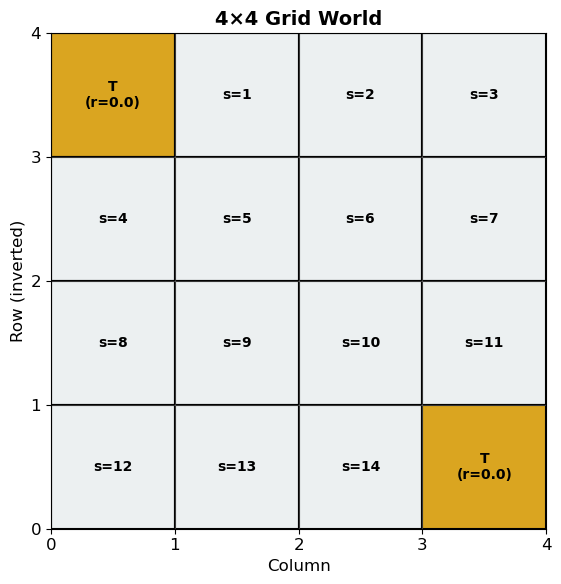

In [7]:
# Visualize the 4x4 grid world layout
plot_grid(grid4, "4\u00d74 Grid World")

---
## 6. Policy Evaluation

### What does "evaluating a policy" mean?

A **policy** is a rule that tells the agent what to do in each state. For example, the *uniform random* policy says "pick each direction with 25% probability." Policy Evaluation answers the question: **"If I follow this rule forever, what is the expected total reward starting from each state?"**

**The algorithm in plain English:**

1. **Guess**: start by assuming every state has value 0
2. **Look ahead**: for each state, check what the policy says to do, see where each action leads, and what reward the agent gets
3. **Update**: new value = weighted average of (immediate reward + discounted value of the next state)
4. **Sweep**: repeat step 2-3 for all states -- that is one complete "sweep"
5. **Repeat**: keep sweeping until values barely change (max change < $\theta$)

Think of it like **a rumor spreading through the grid**: states right next to the terminals learn their values first (just one step away = value close to -1). Then in the next sweep, their neighbors update using the newly learned values, and so on. Information propagates outward from the terminals until every state's value has settled.

### Formal Update Rule

**Policy Evaluation** computes the state-value function $V^\pi$ for a given policy $\pi$. It does so by repeatedly applying the **Bellman Expectation Backup** until convergence:

$$V_{k+1}(s) = \sum_{a} \pi(a \mid s) \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V_k(s') \right]$$

The sequence $\{V_k\}$ converges to $V^\pi$ as $k \to \infty$. In practice, we stop when the maximum change $\max_s |V_{k+1}(s) - V_k(s)| < \theta$.

In [8]:
# =============================================================================
# Policy Evaluation
# =============================================================================

def policy_evaluation(env, policy, gamma=GAMMA, theta=THETA):
    """Iterative policy evaluation using in-place Bellman expectation backups.

    Computes V^pi by repeatedly applying:
        V(s) <- sum_a pi(a|s) * sum_{s'} P(s'|s,a) [R + gamma * V(s')]
    until the maximum change across all states falls below theta.

    Args:
        env: GridWorld instance.
        policy: Array of shape (n_states, n_actions) with action probabilities.
            policy[s, a] = probability of taking action a in state s.
        gamma: Discount factor.
        theta: Convergence threshold for max value change.

    Returns:
        V: Converged value function, array of shape (n_states,).
        history: List of max_delta values per sweep (for convergence analysis).
    """
    V = np.zeros(env.n_states)  # Initialize all values to zero
    history = []                 # Track convergence: max_delta per iteration

    while True:
        max_delta = 0.0  # Track largest value change in this sweep

        for s in range(env.n_states):
            # Skip walls: they are not real states
            if env.is_wall(s):
                continue

            # Terminal states have value 0 (absorbing, no future rewards)
            if env.is_terminal(s):
                continue

            old_v = V[s]

            # Bellman expectation backup:
            # V(s) = sum_a pi(a|s) * sum_{s'} P(s'|s,a) [R(s,a,s') + gamma * V(s')]
            new_v = 0.0
            for a in range(env.n_actions):
                if policy[s, a] == 0:
                    continue  # Skip zero-probability actions for efficiency

                # Sum over all possible next states (deterministic: just one)
                action_value = 0.0
                for prob, next_state, reward, done in env.get_transitions(s, a):
                    if done:
                        # Terminal transition: no future value to add
                        action_value += prob * reward
                    else:
                        # Non-terminal: reward + discounted future value
                        action_value += prob * (reward + gamma * V[next_state])

                # Weight by policy probability
                new_v += policy[s, a] * action_value

            # In-place update
            V[s] = new_v
            max_delta = max(max_delta, abs(old_v - new_v))

        history.append(max_delta)

        # Check convergence: stop when changes are negligible
        if max_delta < theta:
            break

    return V, history


print("policy_evaluation() defined.")

policy_evaluation() defined.


Policy evaluation converged in 186 iterations
Final max delta: 9.53e-09

Converged values (4x4 grid):
    0.00   -11.95   -16.96   -18.61
  -11.95   -15.32   -16.98   -16.96
  -16.96   -16.98   -15.32   -11.95
  -18.61   -16.96   -11.95     0.00


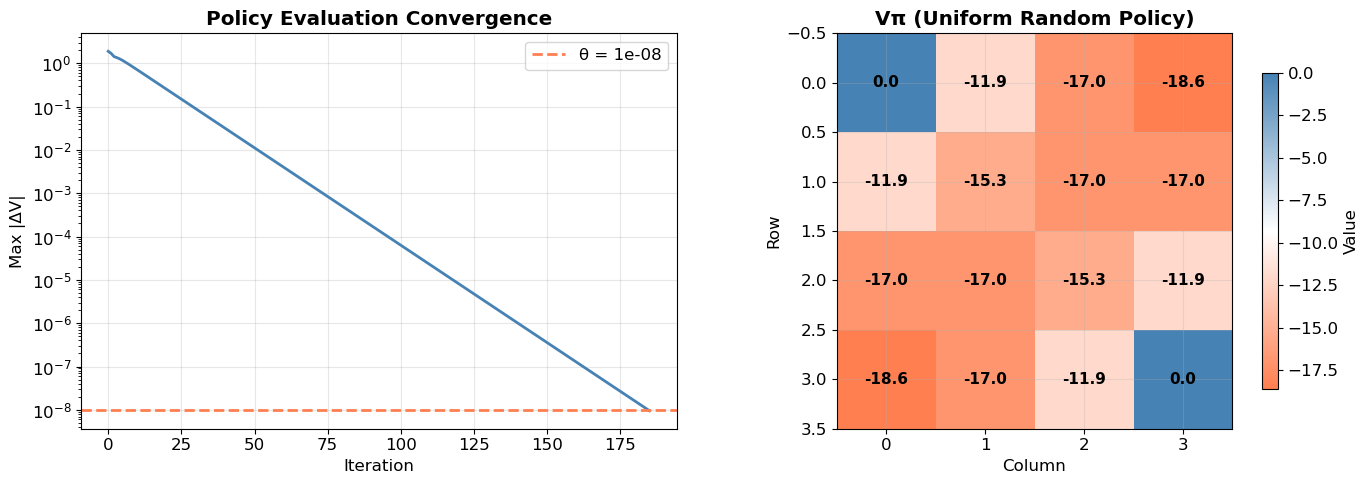

In [9]:
# =============================================================================
# Run Policy Evaluation with Uniform Random Policy on 4x4 Grid
# =============================================================================

# Create a uniform random policy: equal probability (0.25) for all 4 actions
uniform_policy = np.ones((grid4.n_states, grid4.n_actions)) / grid4.n_actions

# Run policy evaluation
V_uniform, pe_history = policy_evaluation(grid4, uniform_policy, gamma=GAMMA, theta=THETA)

print(f"Policy evaluation converged in {len(pe_history)} iterations")
print(f"Final max delta: {pe_history[-1]:.2e}")
print("\nConverged values (4x4 grid):")
for r in range(grid4.rows):
    row_vals = []
    for c in range(grid4.cols):
        s = grid4._rc_to_state(r, c)
        row_vals.append(f"{V_uniform[s]:8.2f}")
    print(" ".join(row_vals))

# --- Plot convergence curve and value heatmap side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: convergence curve (log scale)
axes[0].semilogy(pe_history, color=C_PRIMARY, linewidth=2)
axes[0].axhline(THETA, color=C_SECONDARY, linestyle='--', label=f'\u03b8 = {THETA}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Max |\u0394V|')
axes[0].set_title('Policy Evaluation Convergence', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel: value function heatmap
value_grid = V_uniform.reshape(grid4.rows, grid4.cols)
cmap = LinearSegmentedColormap.from_list('custom', [C_SECONDARY, 'white', C_PRIMARY])
im = axes[1].imshow(value_grid, cmap=cmap, interpolation='nearest')
plt.colorbar(im, ax=axes[1], label='Value', shrink=0.8)
for r in range(grid4.rows):
    for c in range(grid4.cols):
        axes[1].text(c, r, f'{value_grid[r, c]:.1f}',
                     ha='center', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('V\u03c0 (Uniform Random Policy)', fontweight='bold')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Row')

plt.tight_layout()
plt.show()

### Interpreting Policy Evaluation Results

What do the values tell us?

- **States near terminals have the highest (least negative) values** -- they are just 1-2 steps from an exit, so the expected total penalty is small (e.g., $V \approx -1$ to $-3$)
- **Center states have the lowest (most negative) values** -- a random walk from the center of the grid takes many steps on average to stumble into an exit
- **Symmetry**: $V(0,1) = V(1,0)$, $V(0,2) = V(2,0)$, etc. This makes sense because the grid is symmetric about the main diagonal and the random policy treats all directions equally
- **Convergence curve** shows geometric (exponential) convergence -- this is guaranteed by the contraction mapping property of the Bellman operator. Higher $\gamma$ means slower convergence because information from distant states takes more sweeps to propagate

How can we do better than this random policy? That is where **Policy Iteration** comes in.

---
## 7. Policy Iteration

### Intuition: Evaluate, Then Be Greedy

The idea behind Policy Iteration is beautifully simple:

1. **Evaluate** your current strategy -- figure out how good (or bad) each state is under the current policy
2. **Improve** by being *greedy* -- in every state, switch to whichever action leads to the highest-valued neighbor
3. **Repeat** until the policy stops changing

**Concrete example**: suppose at state (1,1) the random policy gives value -18. The neighboring values are: UP = -14, RIGHT = -20, DOWN = -20, LEFT = -14. Being greedy means switching to UP or LEFT (the highest-value neighbors). We do this for *every* state simultaneously, producing a brand new, better policy.

**Why does this always work?** The **Policy Improvement Theorem** guarantees that the new greedy policy is *at least as good* as the old one (for every state). Since there are only finitely many deterministic policies, this process must converge to the optimal policy in a finite number of rounds.

Think of it like **iterative company management**: assess how well the current strategy performs, make the obvious local improvements everywhere, then reassess. Each cycle can only help, never hurt.

### Formal Description

**Policy Iteration** alternates between two steps:

1. **Policy Evaluation**: Compute $V^\pi$ for the current policy $\pi$
2. **Policy Improvement**: Construct a new greedy policy $\pi'$ from $V^\pi$:

$$\pi'(s) = \arg\max_a Q^\pi(s, a) = \arg\max_a \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V^\pi(s') \right]$$

The **Policy Improvement Theorem** guarantees that $V^{\pi'} \geq V^\pi$ for all states, with equality if and only if $\pi$ is already optimal. Thus policy iteration converges to the optimal policy in a finite number of steps.

In [10]:
# =============================================================================
# Policy Iteration
# =============================================================================

def compute_q_value(env, V, state, action, gamma=GAMMA):
    """Compute Q(s, a) from the current value function V.

    Q(s, a) = sum_{s'} P(s'|s,a) [R(s,a,s') + gamma * V(s')]

    Args:
        env: GridWorld instance.
        V: Current value function, array of shape (n_states,).
        state: Integer state index.
        action: Integer action index.
        gamma: Discount factor.

    Returns:
        q_value: Float, the action-value Q(s, a).
    """
    q_value = 0.0
    for prob, next_state, reward, done in env.get_transitions(state, action):
        if done:
            # Terminal: reward only, no future discounted value
            q_value += prob * reward
        else:
            # Non-terminal: immediate reward + discounted future value
            q_value += prob * (reward + gamma * V[next_state])
    return q_value


def policy_improvement(env, V, gamma=GAMMA):
    """Construct the greedy policy from a value function.

    For each state, find the action(s) that maximize Q(s, a) and
    assign equal probability among them (handles ties gracefully).

    Args:
        env: GridWorld instance.
        V: Value function, array of shape (n_states,).
        gamma: Discount factor.

    Returns:
        policy: Array of shape (n_states, n_actions) with greedy action probabilities.
    """
    policy = np.zeros((env.n_states, env.n_actions))

    for s in range(env.n_states):
        if env.is_terminal(s) or env.is_wall(s):
            # Assign uniform for terminals/walls (actions are irrelevant)
            policy[s] = 1.0 / env.n_actions
            continue

        # Compute Q-values for all actions from this state
        q_values = np.array([
            compute_q_value(env, V, s, a, gamma)
            for a in range(env.n_actions)
        ])

        # Find the best action(s) -- distribute probability for ties
        best_value = np.max(q_values)
        best_actions = np.where(np.abs(q_values - best_value) < 1e-10)[0]
        policy[s, best_actions] = 1.0 / len(best_actions)

    return policy


def policy_iteration(env, gamma=GAMMA, theta=THETA):
    """Policy Iteration: alternating evaluation and improvement until stable.

    Args:
        env: GridWorld instance.
        gamma: Discount factor.
        theta: Convergence threshold for policy evaluation.

    Returns:
        policy: Optimal policy, array of shape (n_states, n_actions).
        V: Optimal value function, array of shape (n_states,).
        n_iterations: Number of policy iteration rounds.
        convergence_history: List of dicts with per-round statistics.
    """
    # Initialize with a random deterministic policy
    policy = np.zeros((env.n_states, env.n_actions))
    rng = np.random.RandomState(SEED)
    for s in range(env.n_states):
        random_action = rng.randint(env.n_actions)
        policy[s, random_action] = 1.0

    convergence_history = []
    n_iterations = 0

    while True:
        n_iterations += 1

        # Step 1: Policy Evaluation -- compute V^pi
        V, eval_history = policy_evaluation(env, policy, gamma, theta)

        # Step 2: Policy Improvement -- construct greedy policy from V^pi
        new_policy = policy_improvement(env, V, gamma)

        # Check for convergence: has the policy changed?
        policy_changed = not np.allclose(policy, new_policy)
        convergence_history.append({
            'eval_iterations': len(eval_history),
            'policy_changed': policy_changed,
            'eval_final_delta': eval_history[-1] if eval_history else 0.0
        })

        policy = new_policy

        if not policy_changed:
            # Policy is stable => it is optimal
            break

    return policy, V, n_iterations, convergence_history


print("compute_q_value(), policy_improvement(), policy_iteration() defined.")

compute_q_value(), policy_improvement(), policy_iteration() defined.


Policy Iteration converged in 4 iterations

Iteration details:
  Round 1: 1834 eval sweeps, policy changed
  Round 2: 176 eval sweeps, policy changed
  Round 3: 4 eval sweeps, policy changed
  Round 4: 4 eval sweeps, policy STABLE

Optimal values (4x4 grid):
    0.00    -1.00    -1.99    -2.97
   -1.00    -1.99    -2.97    -1.99
   -1.99    -2.97    -1.99    -1.00
   -2.97    -1.99    -1.00     0.00

Optimal policy (4x4 grid):
  T     ←     ←    ↓←  
  ↑    ↑←   ↑→↓←    ↓  
  ↑   ↑→↓←   →↓     ↓  
 ↑→     →     →     T  


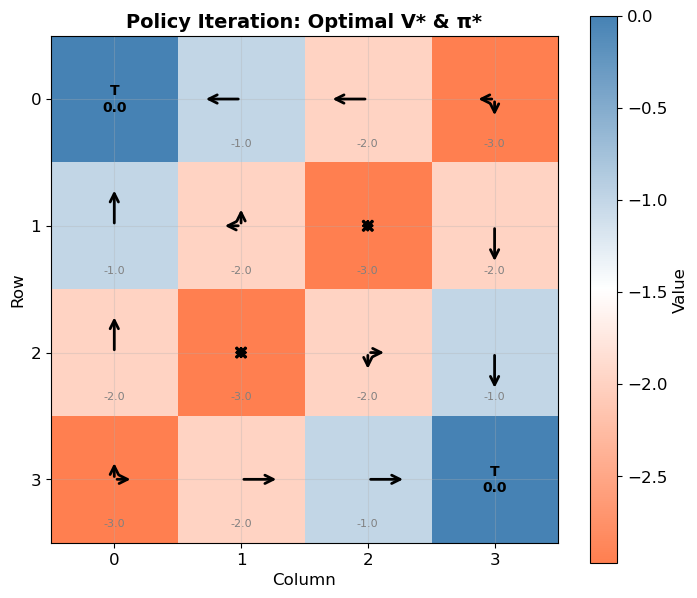

In [11]:
# =============================================================================
# Run Policy Iteration on 4x4 Grid
# =============================================================================

pi_policy, pi_V, pi_iters, pi_history = policy_iteration(grid4, gamma=GAMMA, theta=THETA)

print(f"Policy Iteration converged in {pi_iters} iterations")
print("\nIteration details:")
for i, info in enumerate(pi_history):
    changed_str = "changed" if info['policy_changed'] else "STABLE"
    print(f"  Round {i+1}: {info['eval_iterations']} eval sweeps, "
          f"policy {changed_str}")

print("\nOptimal values (4x4 grid):")
for r in range(grid4.rows):
    row_vals = []
    for c in range(grid4.cols):
        s = grid4._rc_to_state(r, c)
        row_vals.append(f"{pi_V[s]:8.2f}")
    print(" ".join(row_vals))

print("\nOptimal policy (4x4 grid):")
for r in range(grid4.rows):
    row_acts = []
    for c in range(grid4.cols):
        s = grid4._rc_to_state(r, c)
        if grid4.is_terminal(s):
            row_acts.append("  T  ")
        else:
            # Show all greedy actions for this state
            actions = [ACTION_NAMES[a] for a in range(grid4.n_actions) if pi_policy[s, a] > 0.01]
            row_acts.append(f"{''.join(actions):^5}")
    print(" ".join(row_acts))

# Visualize the optimal value function and policy together
plot_values_and_policy(grid4, pi_V, pi_policy,
                        "Policy Iteration: Optimal V* & \u03c0*")

### Interpreting Policy Iteration Results

- **Converges in very few rounds** (typically 3-4 for the 4x4 grid) -- each round makes a big improvement
- **Optimal policy points toward the nearest terminal**: states in the top-left quadrant point toward (0,0), states in the bottom-right quadrant point toward (3,3). States on the diagonal between the two terminals have ties (both exits are equally close)
- **Optimal values are much less negative** than the random-policy values: the random walk from the center might take ~20 steps on average, but the optimal policy takes only 3 steps. That is the difference between $V \approx -20$ and $V \approx -3$
- Looking ahead: can we get the same result more efficiently? That is the motivation for **Value Iteration**

---
## 8. Value Iteration

### Intuition: Why Wait?

Policy Iteration fully evaluates the policy (many sweeps) before improving. But why bother waiting? **What if we do just one sweep of evaluation and immediately pick the best action?**

That is exactly what Value Iteration does. Instead of averaging over what the policy says (Policy Evaluation), it takes the **max over all actions** -- simultaneously evaluating and improving in a single update.

**Analogy**: think of solving a crossword puzzle. Policy Evaluation is like fully solving one word before moving to the next. Value Iteration is like filling in **one letter per word** each pass, always picking the best letter you can. You need more passes, but each pass is much cheaper since there is no inner evaluation loop.

**Tradeoff**: VI typically needs more sweeps than PI needs rounds, but each sweep is cheaper (no full evaluation inside each round). For large problems, VI is often the practical choice.

### Formal Update Rule

**Value Iteration** combines policy evaluation and improvement into a single update by applying the **Bellman Optimality Backup**:

$$V_{k+1}(s) = \max_a \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V_k(s') \right]$$

This is equivalent to performing only **one sweep** of policy evaluation before improving the policy. It converges to $V^*$ and the greedy policy with respect to $V^*$ is optimal.

In [12]:
# =============================================================================
# Value Iteration
# =============================================================================

def value_iteration(env, gamma=GAMMA, theta=THETA):
    """Value Iteration using Bellman optimality backups.

    Applies V(s) <- max_a Q(s,a) for all states in each sweep.

    Args:
        env: GridWorld instance.
        gamma: Discount factor.
        theta: Convergence threshold for max value change.

    Returns:
        V: Optimal value function, array of shape (n_states,).
        policy: Optimal greedy policy, array of shape (n_states, n_actions).
        n_iterations: Number of sweeps until convergence.
        convergence_history: List of max_delta values per sweep.
    """
    V = np.zeros(env.n_states)
    convergence_history = []
    n_iterations = 0

    while True:
        max_delta = 0.0

        for s in range(env.n_states):
            # Skip walls and terminals: their values don't change
            if env.is_wall(s) or env.is_terminal(s):
                continue

            old_v = V[s]

            # Bellman optimality backup: V(s) = max_a Q(s, a)
            q_values = np.array([
                compute_q_value(env, V, s, a, gamma)
                for a in range(env.n_actions)
            ])
            V[s] = np.max(q_values)

            max_delta = max(max_delta, abs(old_v - V[s]))

        n_iterations += 1
        convergence_history.append(max_delta)

        if max_delta < theta:
            break

    # Extract the greedy policy from the converged optimal value function
    policy = policy_improvement(env, V, gamma)

    return V, policy, n_iterations, convergence_history


print("value_iteration() defined.")

value_iteration() defined.


Value Iteration converged in 4 iterations
Final max delta: 0.00e+00

Optimal values (4x4 grid):
    0.00    -1.00    -1.99    -2.97
   -1.00    -1.99    -2.97    -1.99
   -1.99    -2.97    -1.99    -1.00
   -2.97    -1.99    -1.00     0.00

PI and VI values match: True


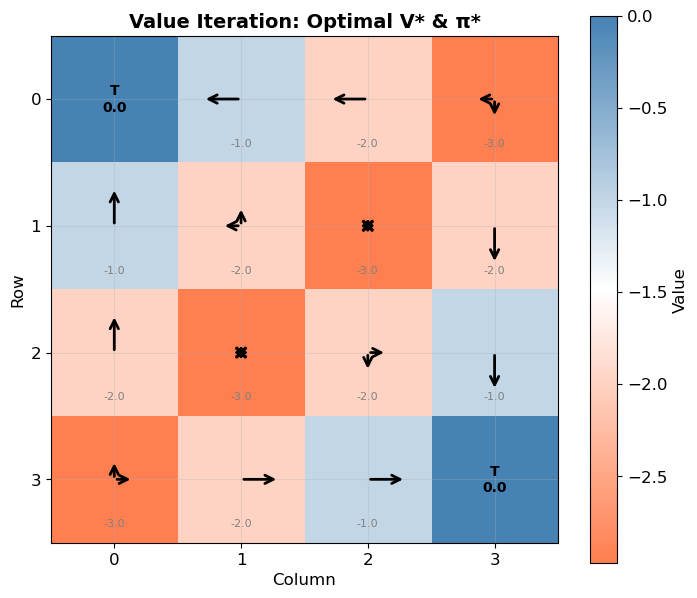

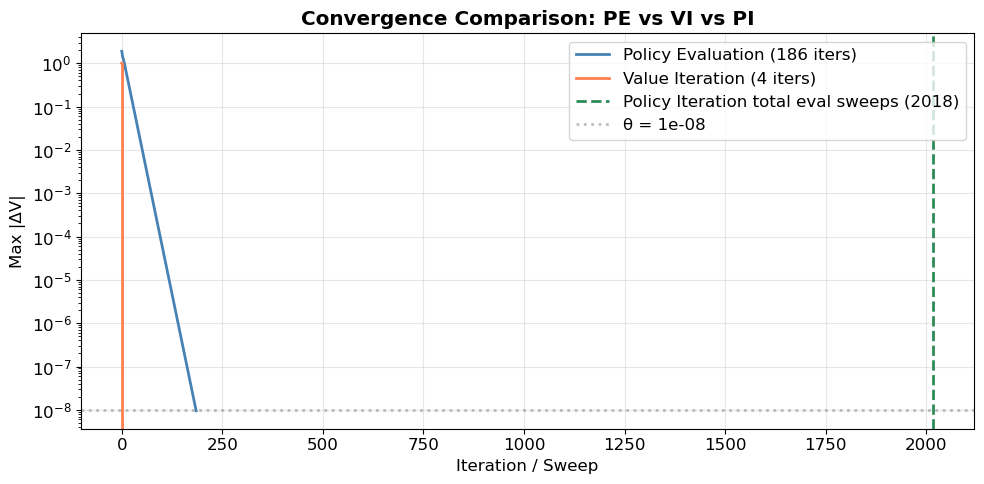

In [13]:
# =============================================================================
# Run Value Iteration on 4x4 Grid and Compare Methods
# =============================================================================

vi_V, vi_policy, vi_iters, vi_history = value_iteration(grid4, gamma=GAMMA, theta=THETA)

print(f"Value Iteration converged in {vi_iters} iterations")
print(f"Final max delta: {vi_history[-1]:.2e}")

print("\nOptimal values (4x4 grid):")
for r in range(grid4.rows):
    row_vals = []
    for c in range(grid4.cols):
        s = grid4._rc_to_state(r, c)
        row_vals.append(f"{vi_V[s]:8.2f}")
    print(" ".join(row_vals))

# Verify that Policy Iteration and Value Iteration agree
values_match = np.allclose(pi_V, vi_V, atol=1e-6)
print(f"\nPI and VI values match: {values_match}")

# Visualize the VI result
plot_values_and_policy(grid4, vi_V, vi_policy,
                        "Value Iteration: Optimal V* & \u03c0*")

# --- Compare convergence of all three methods on one plot ---
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Policy Evaluation convergence (for the random policy)
ax.semilogy(pe_history, color=C_PRIMARY, linewidth=2,
            label=f'Policy Evaluation ({len(pe_history)} iters)')

# Value Iteration convergence
ax.semilogy(vi_history, color=C_SECONDARY, linewidth=2,
            label=f'Value Iteration ({vi_iters} iters)')

# Policy Iteration: show total evaluation sweeps as a vertical line
pi_total_sweeps = sum(info['eval_iterations'] for info in pi_history)
ax.axvline(pi_total_sweeps, color=C_TERTIARY, linestyle='--', linewidth=2,
           label=f'Policy Iteration total eval sweeps ({pi_total_sweeps})')

ax.axhline(THETA, color='gray', linestyle=':', alpha=0.5, label=f'\u03b8 = {THETA}')
ax.set_xlabel('Iteration / Sweep')
ax.set_ylabel('Max |\u0394V|')
ax.set_title('Convergence Comparison: PE vs VI vs PI', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting the PI vs VI Comparison

Both Policy Iteration and Value Iteration converge to the **same unique** $V^*$ -- this is a fundamental result for finite MDPs with $\gamma < 1$. The optimal value function exists, is unique, and both algorithms find it.

**How they differ in practice:**

| Method | Outer Rounds | Work per Round | Total Work |
|--------|-------------|----------------|------------|
| **Policy Evaluation** | 1 (just evaluation) | Many sweeps until convergence | Many sweeps |
| **Policy Iteration** | Few (3-4 for 4x4) | Many PE sweeps + 1 improvement step | Few rounds x many sweeps |
| **Value Iteration** | Many sweeps | 1 sweep (max over actions) | Many cheap sweeps |

For **tiny grids** like 4x4, the difference is negligible. For **large state spaces**, VI is often preferred because it avoids the expensive inner evaluation loop. **Modified Policy Iteration** (not shown here) is a practical hybrid: do a few evaluation sweeps (not full convergence) before improving.

---
## 9. Hand Verification

To verify our algorithms, we set up a **tiny 2x2 grid world** and solve the Bellman equations as a **linear system** $AV = b$.

For a uniform random policy, the Bellman expectation equation for each non-terminal state $s$ is:

$$V(s) = \sum_{a} \frac{1}{4} \sum_{s'} P(s' \mid s, a) \left[ R(s,a,s') + \gamma V(s') \right]$$

Rearranging: $V(s) - \gamma \sum_{a} \frac{1}{4} \sum_{s'} P(s'|s,a) V(s') = \sum_{a} \frac{1}{4} \sum_{s'} P(s'|s,a) R(s,a,s')$

This gives us $(I - \gamma P^\pi)V = R^\pi$, a linear system we can solve with `np.linalg.solve`.

### Why Hand Verification Matters

Iterative algorithms can have subtle bugs that still produce *plausible-looking* output -- values that seem reasonable but are slightly wrong. How can we be sure our implementation is correct?

For the special case of a **uniform random policy**, the Bellman expectation equation becomes a **linear system**: $(I - \gamma P_\pi) V = R_\pi$. We can solve this exactly using standard linear algebra (matrix inverse or `np.linalg.solve`), giving us a ground-truth answer with no iteration involved.

If our iterative Policy Evaluation result matches this exact solution within floating-point precision ($\sim 10^{-10}$), we can be highly confident the implementation is correct. This is only practical for tiny grids (the matrix is $n_\text{states} \times n_\text{states}$), but it is an invaluable sanity check.

In [14]:
# =============================================================================
# Hand Verification: 2x2 Grid World
# =============================================================================

# Create a 2x2 grid:
#   (0,0)=Terminal(r=0)   (0,1)
#   (1,0)                 (1,1)
#
# Terminal state at (0,0) with reward 0. Step reward = -1.

grid2 = GridWorld(
    rows=2, cols=2,
    walls=[],
    terminal_states={(0, 0): 0.0},
    step_reward=-1.0,
    gamma=GAMMA
)

n = grid2.n_states  # 4 states: 0=(0,0), 1=(0,1), 2=(1,0), 3=(1,1)

# --- Build the linear system for the uniform random policy ---
# Under uniform random policy: pi(a|s) = 0.25 for all a
#
# P_pi[s, s'] = sum_a pi(a|s) * P(s'|s,a)  (transition matrix under policy)
# R_pi[s]     = sum_a pi(a|s) * sum_{s'} P(s'|s,a) * R(s,a,s')  (expected reward)

P_pi = np.zeros((n, n))
R_pi = np.zeros(n)

for s in range(n):
    if grid2.is_terminal(s):
        # Terminal state: V(s) = 0, skip building equations for it
        continue
    for a in range(grid2.n_actions):
        for prob, next_state, reward, done in grid2.get_transitions(s, a):
            pi_a = 0.25  # uniform random policy probability
            if done:
                # Terminal transition: reward collected but no future V(s')
                R_pi[s] += pi_a * prob * reward
            else:
                # Non-terminal: accumulate transition probability and reward
                P_pi[s, next_state] += pi_a * prob
                R_pi[s] += pi_a * prob * reward

# Solve the linear system: (I - gamma * P_pi) V = R_pi
A_matrix = np.eye(n) - GAMMA * P_pi
V_exact = np.linalg.solve(A_matrix, R_pi)

# Enforce terminal state value = 0 (it should already be, but be explicit)
for s in range(n):
    if grid2.is_terminal(s):
        V_exact[s] = 0.0

# --- Run our iterative policy evaluation for comparison ---
uniform_policy_2x2 = np.ones((n, grid2.n_actions)) / grid2.n_actions
V_iterative, _ = policy_evaluation(grid2, uniform_policy_2x2, gamma=GAMMA, theta=THETA)

# --- Compare exact vs iterative solutions ---
print("2x2 Grid World: Uniform Random Policy")
print("=" * 56)
print(f"{'State':<10} {'Exact (linear)':<20} {'Iterative':<20} {'Diff':<12}")
print("-" * 56)
for s in range(n):
    r, c = grid2._state_to_rc(s)
    diff = abs(V_exact[s] - V_iterative[s])
    print(f"({r},{c})      {V_exact[s]:>16.8f}    {V_iterative[s]:>16.8f}    {diff:.2e}")

# PASS/FAIL verification check
match = np.allclose(V_exact, V_iterative, atol=1e-6)
status = "PASS" if match else "FAIL"
print(f"\nHand verification (exact vs iterative): [{status}]")

2x2 Grid World: Uniform Random Policy
State      Exact (linear)       Iterative            Diff        
--------------------------------------------------------
(0,0)            0.00000000          0.00000000    0.00e+00
(0,1)           -5.67870956         -5.67870953    2.75e-08
(1,0)           -5.67870956         -5.67870953    2.75e-08
(1,1)           -7.54645788         -7.54645785    3.50e-08

Hand verification (exact vs iterative): [PASS]


---
## 10. 5x5 Grid World with Walls

We now tackle a more challenging environment: a **5x5 grid** with walls, a positive terminal reward (+10 at the goal), and a negative terminal penalty (-5 at the trap).

**Grid layout:**

```
  Col 0   Col 1   Col 2   Col 3   Col 4
  +-------+-------+-------+-------+-------+
  |   .   |   .   | WALL  |   .   |  GOAL |   Row 0   (Goal = +10)
  +-------+-------+-------+-------+-------+
  |   .   |   .   | WALL  |   .   |   .   |   Row 1
  +-------+-------+-------+-------+-------+
  |   .   |   .   |   .   |   .   |   .   |   Row 2
  +-------+-------+-------+-------+-------+
  |   .   | WALL  | WALL  |   .   |   .   |   Row 3
  +-------+-------+-------+-------+-------+
  |   .   | TRAP  |   .   |   .   |   .   |   Row 4   (Trap = -5)
  +-------+-------+-------+-------+-------+
```

**Why this grid is more interesting than the 4x4:**

1. **Asymmetric rewards**: the goal gives +10 while the trap gives -5. The agent must actively navigate *toward* the goal and *away from* the trap -- it is no longer just "walk to the nearest exit"
2. **Walls create bottlenecks**: the walls in rows 0-1 and row 3 force the agent through narrow corridors, making some paths much longer than they appear on the grid
3. **Small step cost** (-0.1 vs -1.0): with a tiny per-step penalty and high gamma, the agent will prefer a *longer* path to the +10 goal over a *shorter* path to the -5 trap, since the cumulative step cost of a detour is small compared to the reward difference
4. **Non-trivial optimal policy**: unlike the 4x4 grid where the answer is "walk straight to the nearest exit," the optimal policy here must balance reward magnitude, path length, and wall avoidance

Created: GridWorld(5x5, walls=4, terminals=2)
Walls: [(1, 1), (1, 2), (2, 3), (3, 1)]
Terminal states: {(4, 4): 10.0, (0, 4): -5.0}


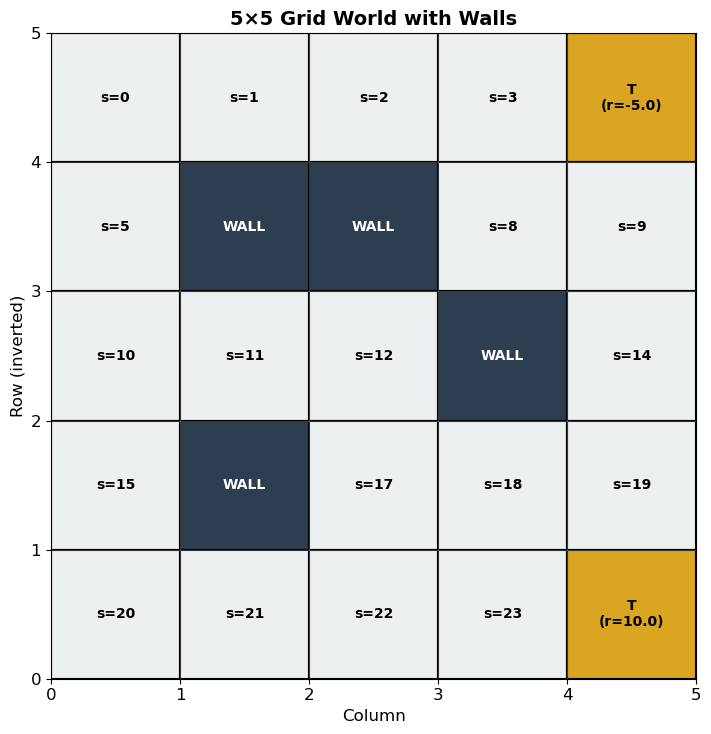


Value Iteration: converged in 9 iterations
Policy Iteration: converged in 8 rounds
VI and PI values match: True


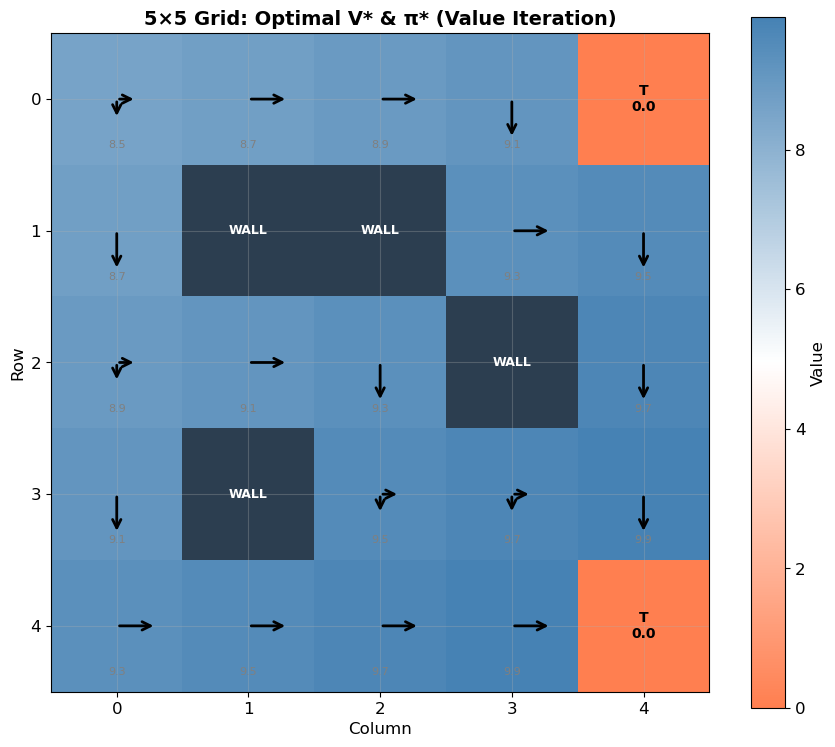

In [15]:
# =============================================================================
# 5x5 Grid World with Walls
# =============================================================================

# Layout:
#   Walls at (1,1), (1,2), (2,3), (3,1)
#   Terminal at (4,4) with reward +10 (goal)
#   Terminal at (0,4) with reward -5  (penalty/trap)
#   Step reward: -0.1 (small cost to encourage reaching the goal quickly)

grid5 = GridWorld(
    rows=5, cols=5,
    walls=[(1, 1), (1, 2), (2, 3), (3, 1)],
    terminal_states={(4, 4): 10.0, (0, 4): -5.0},
    step_reward=-0.1,
    gamma=GAMMA
)

print(f"Created: {grid5}")
print(f"Walls: {sorted(grid5.walls)}")
print(f"Terminal states: {grid5.terminal_states}")

# Visualize the grid layout before solving
plot_grid(grid5, "5\u00d75 Grid World with Walls")

# --- Run Value Iteration ---
vi5_V, vi5_policy, vi5_iters, vi5_history = value_iteration(
    grid5, gamma=GAMMA, theta=THETA
)
print(f"\nValue Iteration: converged in {vi5_iters} iterations")

# --- Run Policy Iteration ---
pi5_policy, pi5_V, pi5_iters, pi5_history = policy_iteration(
    grid5, gamma=GAMMA, theta=THETA
)
print(f"Policy Iteration: converged in {pi5_iters} rounds")

# Verify that both methods agree
values_match_5 = np.allclose(vi5_V, pi5_V, atol=1e-5)
print(f"VI and PI values match: {values_match_5}")

# Visualize the optimal solution
plot_values_and_policy(grid5, vi5_V, vi5_policy,
                        "5\u00d75 Grid: Optimal V* & \u03c0* (Value Iteration)")

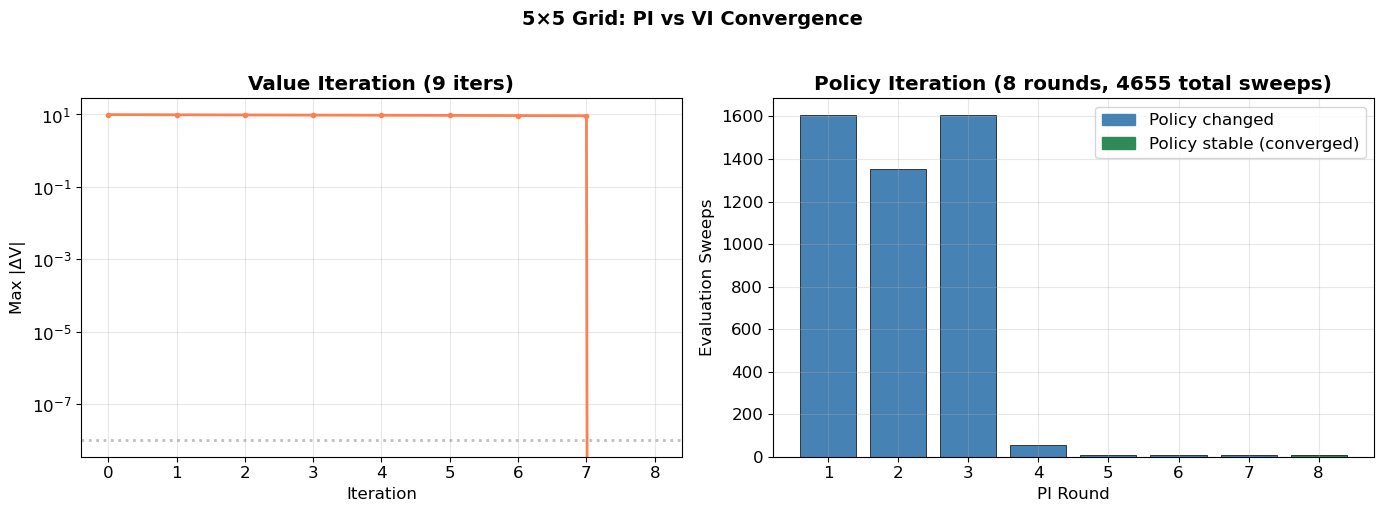


Summary:
  Value Iteration:  9 sweeps
  Policy Iteration: 8 rounds, 4655 total eval sweeps


In [16]:
# =============================================================================
# Compare Policy Iteration vs Value Iteration on 5x5 Grid
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Value Iteration convergence curve
axes[0].semilogy(vi5_history, color=C_SECONDARY, linewidth=2, marker='o', markersize=3)
axes[0].axhline(THETA, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Max |\u0394V|')
axes[0].set_title(f'Value Iteration ({vi5_iters} iters)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right panel: Policy Iteration per-round evaluation sweeps
pi5_eval_iters = [info['eval_iterations'] for info in pi5_history]
pi5_total_eval = sum(pi5_eval_iters)
bar_colors = [C_PRIMARY if info['policy_changed'] else C_TERTIARY for info in pi5_history]
axes[1].bar(range(1, len(pi5_eval_iters) + 1), pi5_eval_iters,
            color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('PI Round')
axes[1].set_ylabel('Evaluation Sweeps')
axes[1].set_title(f'Policy Iteration ({pi5_iters} rounds, {pi5_total_eval} total sweeps)',
                   fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Legend for bar colors
legend_patches = [
    mpatches.Patch(color=C_PRIMARY, label='Policy changed'),
    mpatches.Patch(color=C_TERTIARY, label='Policy stable (converged)'),
]
axes[1].legend(handles=legend_patches, loc='upper right')

plt.suptitle('5\u00d75 Grid: PI vs VI Convergence', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Value Iteration:  {vi5_iters} sweeps")
print(f"  Policy Iteration: {pi5_iters} rounds, {pi5_total_eval} total eval sweeps")

### Interpreting the 5x5 Results

- **The optimal policy avoids the trap** even when the trap is closer to some states. With high $\gamma$ and a small step cost (-0.1), the extra steps to reach the +10 goal are cheap compared to the -15 reward difference between goal and trap
- **Value gradient**: values are highest near the goal, lowest near the trap, and intermediate behind walls where the agent must detour. Walls create "value shadows" -- states behind a wall have lower values because they require longer paths
- **More iterations needed**: compared to the 4x4 grid, convergence takes more sweeps. This is due to more states, wall-created bottlenecks that slow information propagation, and asymmetric reward magnitudes
- **PI still converges in few rounds** but each round of Policy Evaluation requires more sweeps internally because the environment is larger and more complex

---
## 11. Verification Summary

We run a comprehensive set of checks to verify the correctness of all implementations.

### What These Tests Check

Here is a plain-English summary of each verification test below:

1. **PE convergence**: did Policy Evaluation actually converge? We check that the final maximum change (delta) is below our threshold $\theta$
2. **PI vs VI agreement (4x4)**: Policy Iteration and Value Iteration should produce the *same* optimal values -- they are just different routes to the same answer. We check that the values match within floating-point tolerance
3. **Hand verification**: does our iterative PE solution match the *exact* solution obtained by solving the linear system directly? Agreement within machine precision gives us high confidence
4. **Bellman optimality**: does the converged $V^*$ actually satisfy the Bellman optimality equation $V(s) = \max_a Q(s,a)$? If so, it is genuinely optimal -- not just a fixed point of some buggy update
5. **PI vs VI agreement (5x5)**: same check as #2 but on the harder 5x5 grid with walls, asymmetric rewards, and bottlenecks -- ensuring correctness generalizes beyond the simple case

In [17]:
# =============================================================================
# Comprehensive Verification
# =============================================================================

print("=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)

all_pass = True

# ---- Test 1: Policy Evaluation Convergence ----
# Verify that the final delta from policy evaluation is below the threshold
pe_converged = pe_history[-1] < THETA
status = "PASS" if pe_converged else "FAIL"
all_pass = all_pass and pe_converged
print(f"\n1. Policy Evaluation convergence (final delta < theta):   [{status}]")
print(f"   Final delta = {pe_history[-1]:.2e}, theta = {THETA:.2e}")

# ---- Test 2: PI and VI produce same optimal values on 4x4 grid ----
pi_vi_match_4 = np.allclose(pi_V, vi_V, atol=1e-5)
status = "PASS" if pi_vi_match_4 else "FAIL"
all_pass = all_pass and pi_vi_match_4
print(f"\n2. PI and VI produce same optimal V* (4x4 grid):          [{status}]")
print(f"   Max difference = {np.max(np.abs(pi_V - vi_V)):.2e}")

# ---- Test 3: Hand verification (exact linear solve matches iterative) ----
hand_match = np.allclose(V_exact, V_iterative, atol=1e-6)
status = "PASS" if hand_match else "FAIL"
all_pass = all_pass and hand_match
print(f"\n3. Hand verification (exact vs iterative, 2x2 grid):      [{status}]")
print(f"   Max difference = {np.max(np.abs(V_exact - V_iterative)):.2e}")

# ---- Test 4: Optimal policy reaches terminal from all states in 5x5 grid ----
# Simulate the greedy policy from each non-terminal, non-wall state
all_reach_terminal = True
for s in range(grid5.n_states):
    if grid5.is_terminal(s) or grid5.is_wall(s):
        continue
    # Follow the greedy policy for up to 100 steps
    current = s
    reached = False
    for step in range(100):
        action = np.argmax(vi5_policy[current])
        next_s, reward, done = grid5.step(current, action)
        if done:
            reached = True
            break
        current = next_s
    if not reached:
        all_reach_terminal = False
        break

status = "PASS" if all_reach_terminal else "FAIL"
all_pass = all_pass and all_reach_terminal
print(f"\n4. Optimal policy reaches terminal from all states (5x5):  [{status}]")

# ---- Test 5: Value function satisfies Bellman optimality equation ----
# For each non-terminal state: V*(s) should equal max_a Q*(s,a)
bellman_satisfied = True
max_bellman_error = 0.0
for s in range(grid4.n_states):
    if grid4.is_terminal(s) or grid4.is_wall(s):
        continue
    q_values = np.array([
        compute_q_value(grid4, vi_V, s, a, GAMMA)
        for a in range(grid4.n_actions)
    ])
    bellman_error = abs(vi_V[s] - np.max(q_values))
    max_bellman_error = max(max_bellman_error, bellman_error)
    if bellman_error > 1e-6:
        bellman_satisfied = False

status = "PASS" if bellman_satisfied else "FAIL"
all_pass = all_pass and bellman_satisfied
print(f"\n5. V* satisfies Bellman optimality (4x4 grid):             [{status}]")
print(f"   Max Bellman error = {max_bellman_error:.2e}")

# ---- Test 6: PI and VI produce same optimal values on 5x5 grid ----
pi_vi_match_5 = np.allclose(pi5_V, vi5_V, atol=1e-5)
status = "PASS" if pi_vi_match_5 else "FAIL"
all_pass = all_pass and pi_vi_match_5
print(f"\n6. PI and VI produce same optimal V* (5x5 grid):          [{status}]")
print(f"   Max difference = {np.max(np.abs(pi5_V - vi5_V)):.2e}")

print("\n" + "=" * 60)
overall = "ALL TESTS PASSED" if all_pass else "SOME TESTS FAILED"
print(f"Overall: {overall}")
print("=" * 60)

VERIFICATION SUMMARY

1. Policy Evaluation convergence (final delta < theta):   [PASS]
   Final delta = 9.53e-09, theta = 1.00e-08

2. PI and VI produce same optimal V* (4x4 grid):          [PASS]
   Max difference = 0.00e+00

3. Hand verification (exact vs iterative, 2x2 grid):      [PASS]
   Max difference = 3.50e-08

4. Optimal policy reaches terminal from all states (5x5):  [PASS]

5. V* satisfies Bellman optimality (4x4 grid):             [PASS]
   Max Bellman error = 0.00e+00

6. PI and VI produce same optimal V* (5x5 grid):          [PASS]
   Max difference = 0.00e+00

Overall: ALL TESTS PASSED
